In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy.integrate import solve_ivp
import capillary_wave_analysis as cwa
import PSD_utils
from scipy.signal import welch

In [2]:
%load_ext autoreload
%autoreload 2

In [101]:
import detOpInf_utils as detOpinf

In [4]:
# Matplotlib customizations
plt.rc("axes.spines", right=True, top=True)
# plt.rc("figure", dpi=300, figsize=(9, 3))
plt.rc("font", family="serif")
plt.rc("legend", edgecolor="none", frameon=False)

# x ticks for log2 scale
log2_xticks = np.array([8, 16, 32, 64], dtype=float)

import warnings
warnings.filterwarnings("ignore")

In [102]:
power_labels = {
    "0p04": list("abefghi"),
    "0p07": list("abcdfghij"),
    "0p08": list("aefhij"),
    "0p10": list("bcdefhijk"),  # or "bcdefhijklmnopq"
    "0p15": list("abcdefghij"),
    "0p18": list("abcdefghij"),
    "0p20": list("abcdefghijklmn"),
    "0p25": list("abcdefghij"),
    "0p30": list("abcdefghijklmn"),
    "0p35": list("abcdefghijklmnop"),
}

power = "0p07"

Q, t, x, nx = detOpinf.load_Q_dataset(power, power_labels[power])

In [103]:
Q_split, Qstate_all, X_mean, tt = detOpinf.preprocess_Q(Q, t, labels = power_labels[power])

In [ ]:
from scipy.linalg import svd
V, svdvals, _ = svd(X_mean, full_matrices=False)

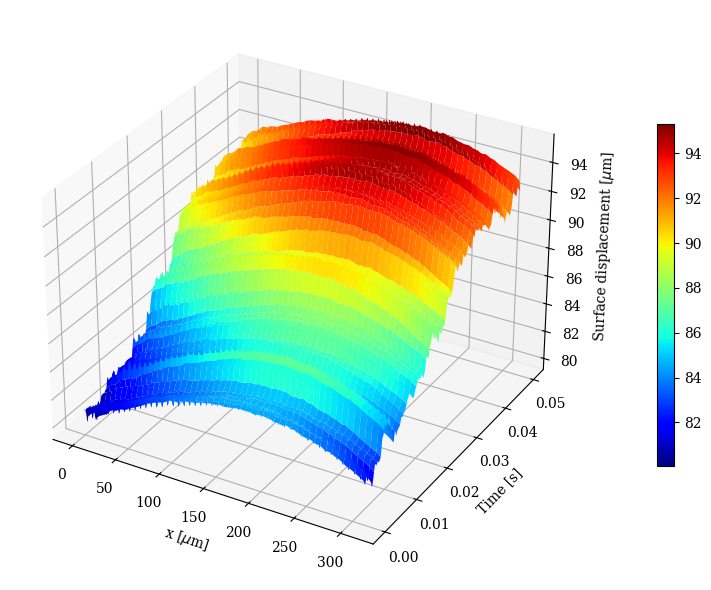

In [105]:
T, X = np.meshgrid(tt, x)
Z = Qstate_all.mean(axis=1)
Z = X_mean

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X, T, Z, cmap='jet', edgecolor='none'
)

ax.set_xlabel('x [$\\mu$m]')
ax.set_ylabel('Time [s]')
ax.set_zlabel('Surface displacement [$\\mu$m]')

fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)
plt.tight_layout()
plt.show()


In [106]:
Q_train = X_mean
t_train = tt

In [ ]:
Q_train, dt, stats = detOpinf.scale_snapshots(Q_train, t_train, mean_subtract=False, scale=False)

Using original snapshots without mean subtraction.

Processed snapshot matrix shape: (200, 5760)
Time vector shape: (5760,)
dt = 8.6806e-06


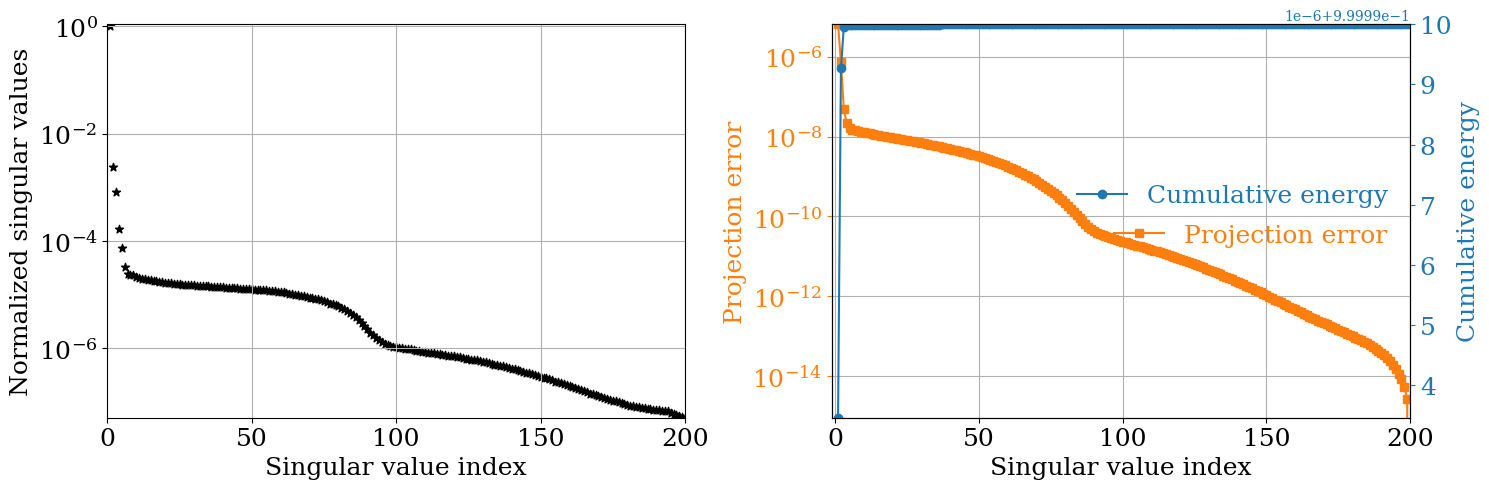

In [109]:
kappa = 0.99
svd_dyn_normalized = svdvals / svdvals[0]

## Compute cumulative and residual energy
cum_energy = np.cumsum(svdvals**2) / np.sum(svdvals**2)
resd_energy = 1 - cum_energy

sig_lim = len(svd_dyn_normalized)  # Number of singular values to plot
# sig_lim = 100

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plot normalized singular values
axs[0].scatter(range(1, len(cum_energy) + 1), svd_dyn_normalized, color='k', marker="*")
axs[0].set(yscale='log', xlim=(0, sig_lim), ylim=(np.min(svd_dyn_normalized[:sig_lim]), 1.1))
axs[0].set_xlabel(r'Singular value index', fontsize=18)
axs[0].set_ylabel('Normalized singular values', fontsize=18)
axs[0].tick_params(axis='x', labelsize=18)
axs[0].tick_params(axis='y', labelsize=18)
axs[0].grid()

# Plot projection error and cumulative energy
ax2 = axs[1].twinx()
axs[1].plot(range(1, len(resd_energy) + 1), resd_energy, color="C1", marker="s", linestyle='-', label="Projection error")
ax2.plot(range(1, len(cum_energy) + 1), cum_energy, color="C0", marker="o", linestyle='-', label="Cumulative energy")

# Set both y-axes to logarithmic scale
axs[1].set_yscale('log')  # Left y-axis (Projection error)
# ax2.set_yscale('log')     # Right y-axis (Cumulative energy)

# Configure left y-axis
axs[1].set(xlim=(-1, sig_lim), ylim=(np.min(resd_energy[:sig_lim]), np.max(resd_energy[:sig_lim])))
axs[1].set_xlabel(r'Singular value index', fontsize=18)
axs[1].set_ylabel('Projection error', fontsize=18)
axs[1].tick_params(axis='y', labelsize=18, colors="C1")
axs[1].yaxis.label.set_color("C1")

# Configure right y-axis
ax2.set(ylim=(np.min(cum_energy[:sig_lim]), np.max(cum_energy[:sig_lim])))
ax2.set_ylabel('Cumulative energy', fontsize=18)
ax2.tick_params(axis='y', labelsize=18, colors="C0")
ax2.yaxis.label.set_color("C0")

# Add legends
ax2.legend(loc="upper right", bbox_to_anchor=(1, 0.65), fontsize=18, labelcolor="C0")
axs[1].legend(loc="upper right", bbox_to_anchor=(1, 0.55), fontsize=18, labelcolor="C1")

# Final adjustments
axs[1].grid()
axs[1].tick_params(axis="x", labelsize=18)
plt.tight_layout()
plt.show()

In [110]:
detROM = detOpinf.OpInfROM(V, Q_train, t_train)

r_dim = 20
Q_hat = detROM.compress_data(r_dim)
Q_hat.shape

(20, 5760)

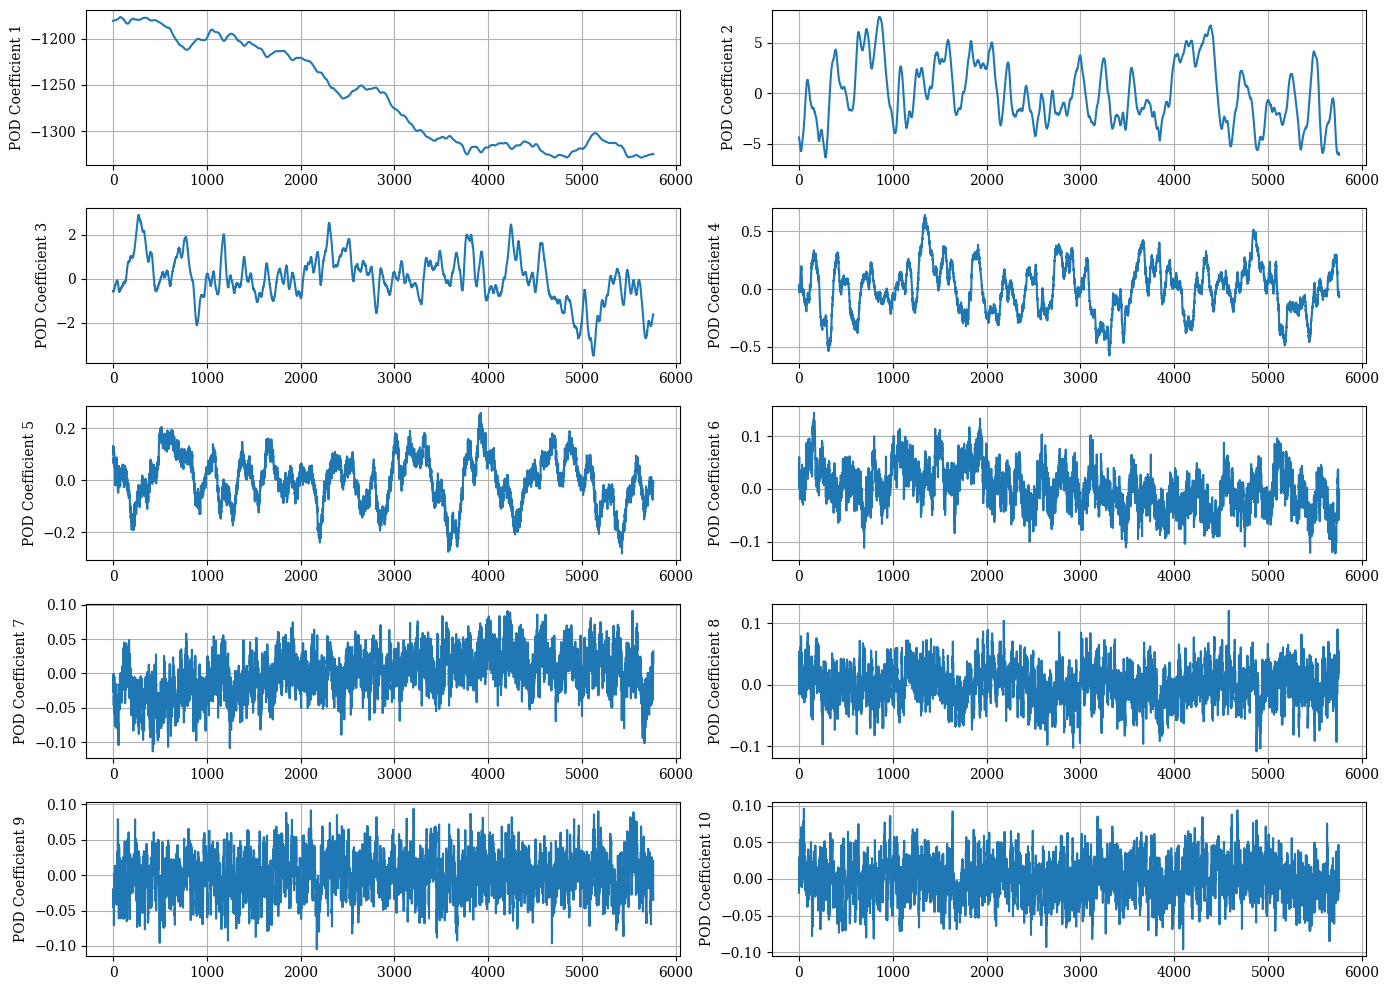

In [111]:
# Plot the first 10 POD coefficients
fig, axes = plt.subplots(5, 2, figsize=(14, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.plot(Q_hat[i,:], label=f"Coefficient {i+1}")
    ax.set_ylabel(f"POD Coefficient {i+1}")
    ax.grid()

plt.tight_layout()
plt.show()

In [144]:
r_test = np.linspace(5, 20, 16).astype(int)
r_test = np.linspace(5, 15, 11).astype(int)

lambda1 = np.logspace(-5, 10, 10)
lambda2 = np.logspace(0, 12, 10)

errors = []
regs = {}

for r in r_test:
    print(f"Testing r = {r}")
    
    Q_hat = detROM.compress_data(r)
    D = detROM.data_mat_generator(Q_hat)

    R = np.zeros_like(Q_hat)
    for j in range(detROM.r):
        R[j, :] = detOpinf.ctr_FD(Q_hat[j, :], detROM.dt, order=8)
    
    min_error, reg_idx = detROM.grid_search(D=D, R=R, t=t_train, Q_hat=Q_hat)
    
    errors.append(min_error)
    regs[r] = reg_idx

Testing r = 5
Testing r = 6


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (16,) and (4,)

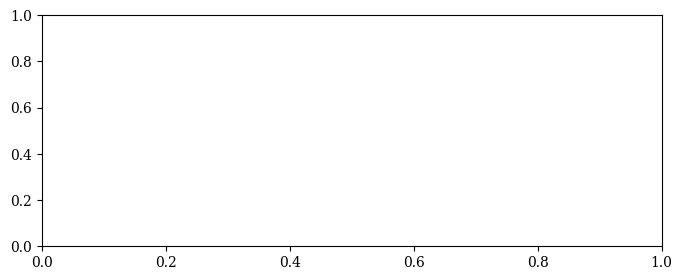

In [143]:
plt.figure(figsize=(8, 3))
plt.plot(r_test, errors, marker='*', color='k')

plt.xlabel("reduced dimension", fontsize=15)
plt.ylabel("Minimum error", fontsize=15)
plt.xticks(r_test, rotation=0, fontsize=15)
plt.yticks(fontsize=15)
plt.grid()
plt.tight_layout()
plt.show()

In [142]:
r_dim = 10
i_min, j_min = regs[r_dim]

lambda1 = np.logspace(-5, +10, 10)
lambda2 = np.logspace(0, +12, 10)

Q_hat = detROM.compress_data(r_dim)
D = detROM.data_mat_generator(Q_hat)

R = np.zeros_like(Q_hat)
for j in range(r_dim):
    R[j,:] = detOpinf.ctr_FD(Q_hat[j,:], dt, order=8)

quad_reg_optimal = [lambda1[i_min], lambda2[j_min]]
c_hat, A_hat, H_hat = detROM.infer_operator(D=D, R=R, lambdas=quad_reg_optimal)
args = (c_hat, A_hat, H_hat)

q0_ = Q_hat[:,0]
qq = solve_ivp(detROM.ROMfunc, t_span=(t_train[0], t_train[-1]), y0=q0_, method='RK45', t_eval=t_train)
q_hat_quadROM = qq.y
print(q_hat_quadROM.shape)

error = la.norm(Q_hat - q_hat_quadROM) / la.norm(Q_hat)
print(f"Low dimensional q_hat error: {error:.4%}")

KeyError: 10

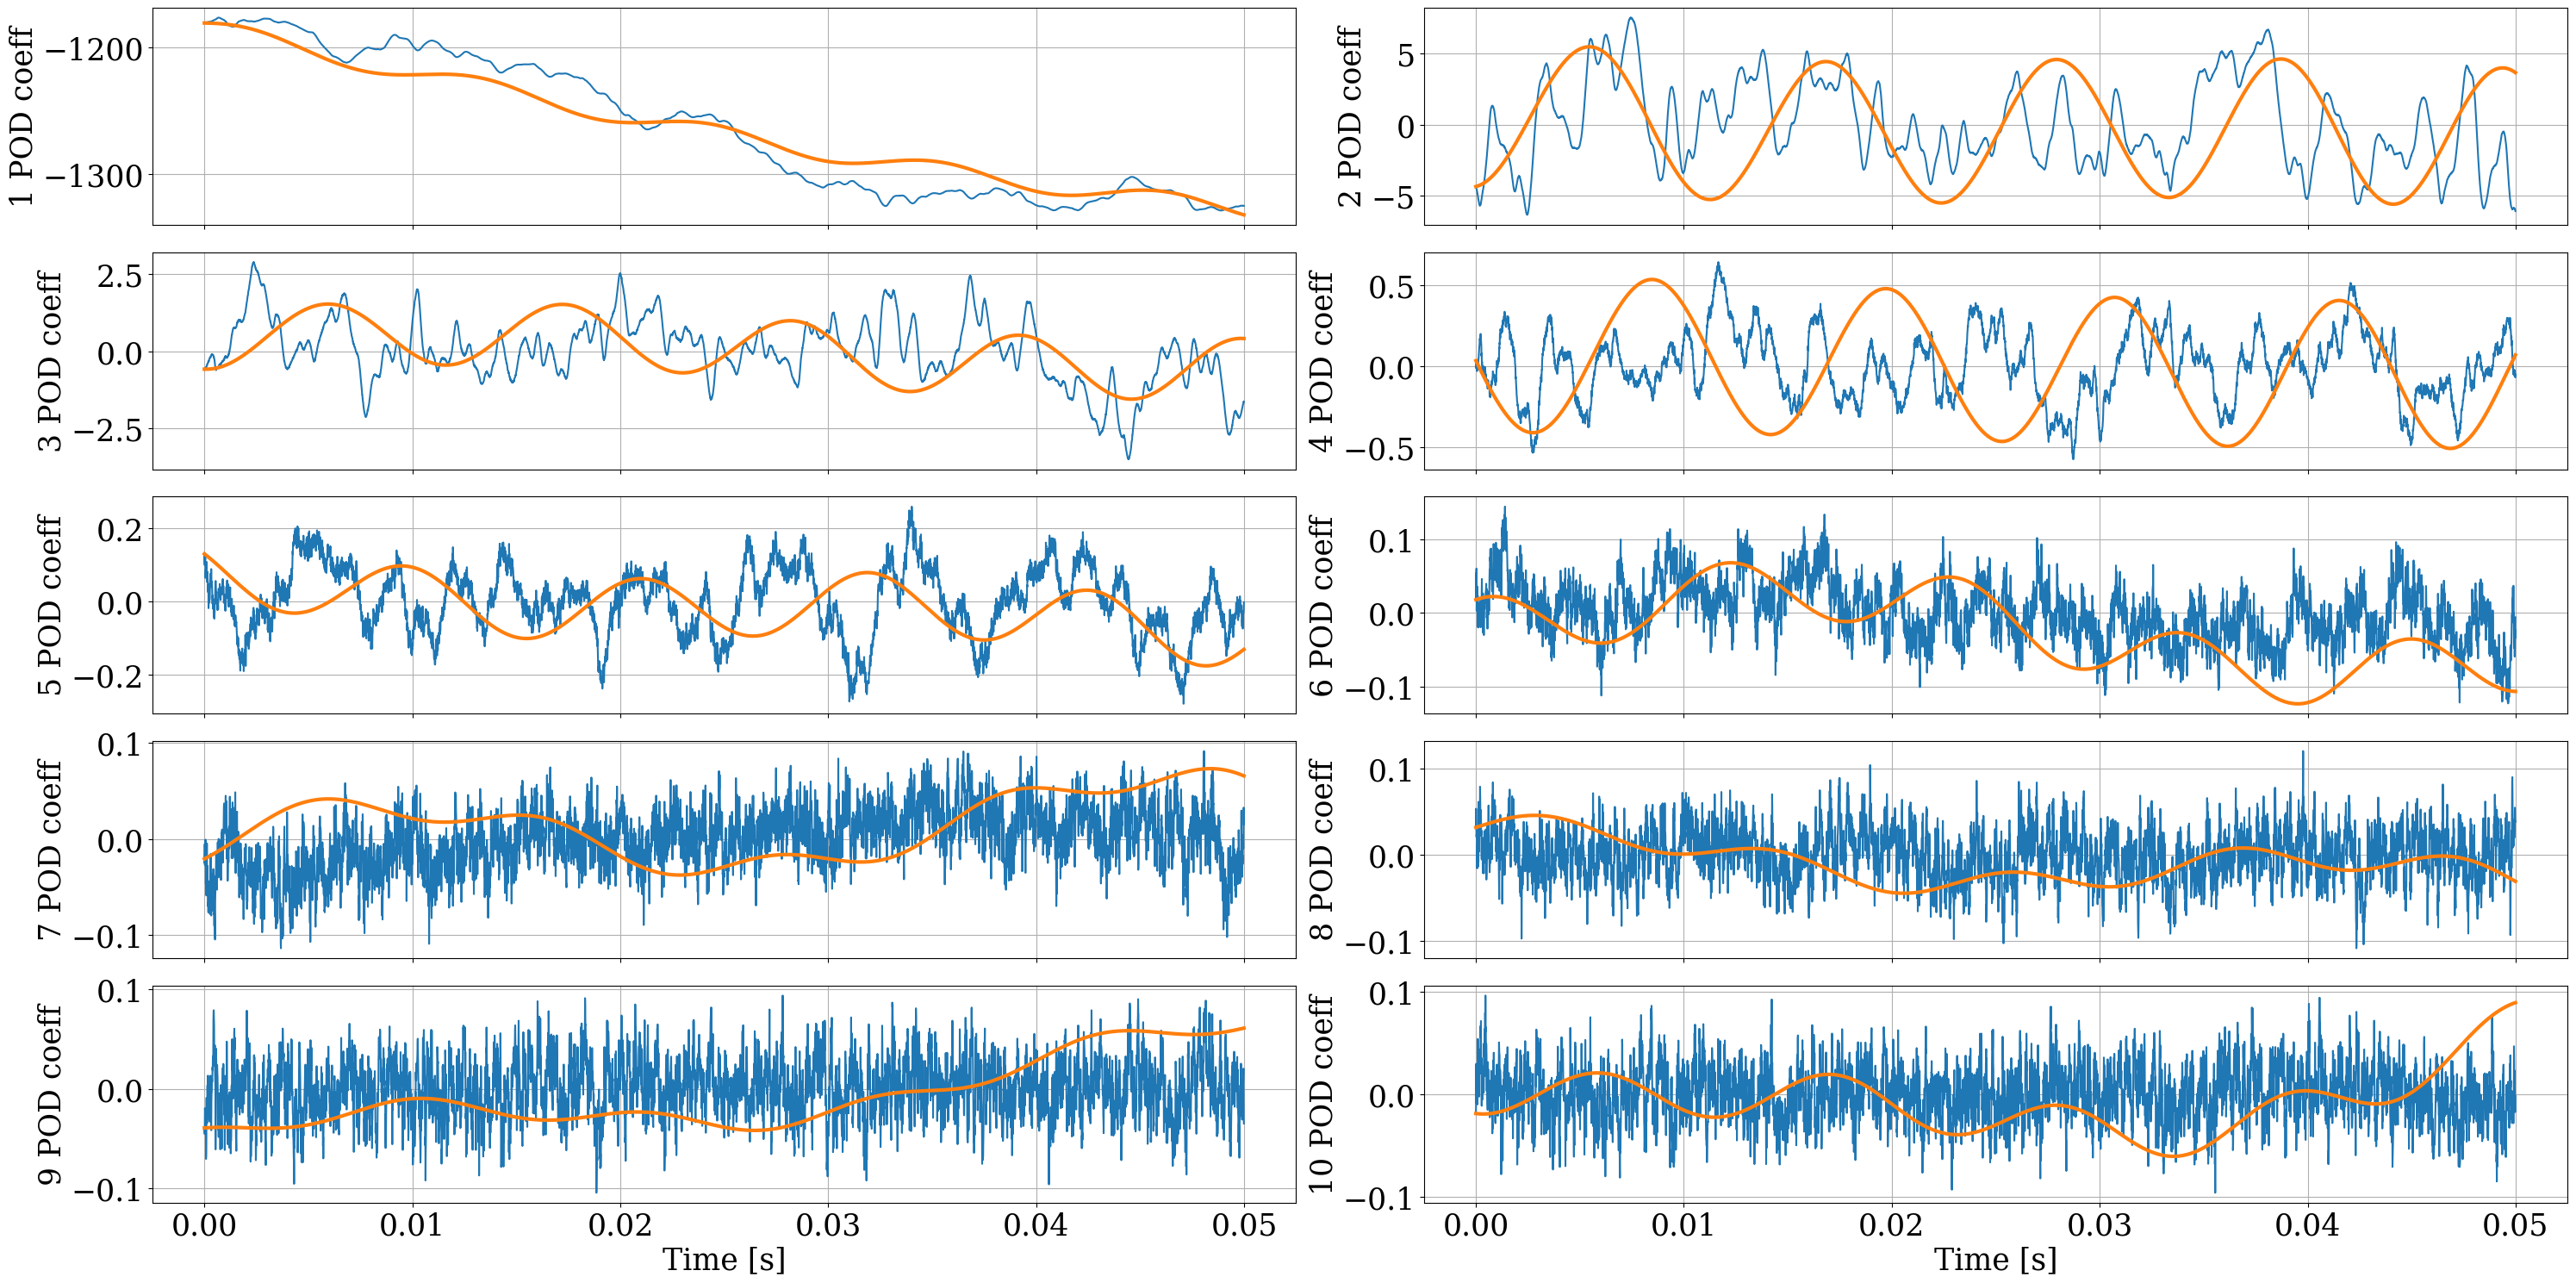

In [134]:
num_coeffs = r_dim

fig, axs = plt.subplots(5, 2, figsize=(30, 15), sharex=True)
axs = axs.flatten()
for ii in range(num_coeffs):
    axs[ii].plot(tt, Q_hat[ii,:], label="experiment", color='C0')
    axs[ii].plot(tt, q_hat_quadROM[ii,:], label="rom", color='C1', linewidth=3)
    axs[ii].set_ylabel(f"{ii+1} POD coeff", size=25)
    axs[ii].tick_params(axis='x', labelsize=25)
    axs[ii].tick_params(axis='y', labelsize=25)
    axs[ii].grid()
axs[-1].set_xlabel("Time [s]", size=25)
axs[-2].set_xlabel("Time [s]", size=25)
plt.tight_layout()
plt.show()

In [127]:
Q_tilde = detROM.decompress_data(q_hat_quadROM)

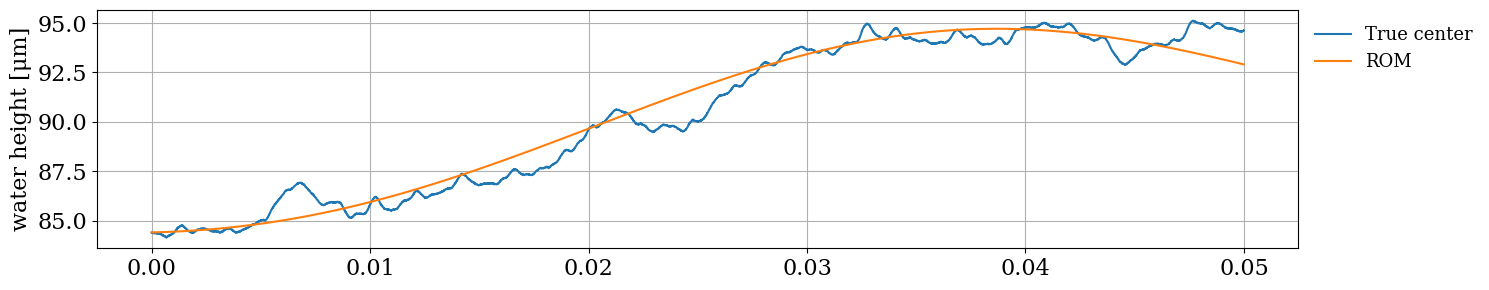

In [128]:
i_center = 100
Q_recon_center = Q_tilde[i_center, :]

plt.figure(figsize=(15, 3))
plt.plot(tt, X_mean[i_center, :], label="True center")
plt.plot(tt, Q_recon_center, label=f"ROM")

plt.ylabel("water height [\u03bcm]", size=16)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.legend(fontsize=13, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.tight_layout()
plt.show()

In [129]:
# Compute PSD at the center point
FS_DHM = 115_200
i_center = 100

k_FOM, psd_FOM, f_FOM, slope_FOM, r2_FOM, i_best_FOM, j_best_FOM = PSD_utils.compute_PSD(X_mean[i_center,:], FS_DHM, 5, 30)
k_ROM, psd_ROM, f_ROM, slope_ROM, r2_ROM, i_best_ROM, j_best_ROM = PSD_utils.compute_PSD(Q_tilde[i_center,:], FS_DHM, 5, 30)

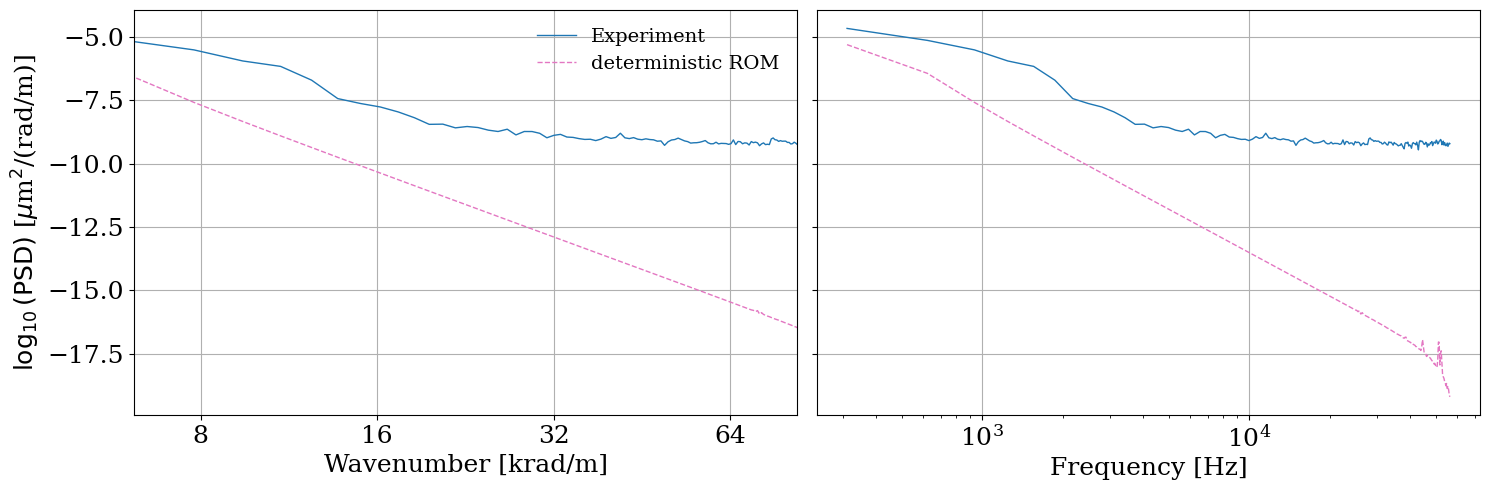

In [130]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ax[0].plot(k_FOM, psd_FOM, color='C0', lw = 1, ls="-", label='Experiment')
ax[0].plot(k_ROM, psd_ROM, color='C6', lw = 1, ls="--", label='deterministic ROM')

ax[1].plot(f_FOM, psd_FOM, color='C0', lw = 1, ls="-", label='Experiment')
ax[1].plot(f_ROM, psd_ROM, color='C6', lw = 1, ls="--", label='deterministic ROM')


ax[0].set_xscale('log', base=2)
ax[0].set_xlim(log2_xticks.min()/1.3, log2_xticks.max()*1.3)
ax[0].set_xticks(log2_xticks)
ax[0].set_xticklabels([str(int(x)) for x in log2_xticks], fontsize=18)
ax[0].tick_params(axis='y', labelsize=18)

ax[1].set_xscale('log')

ax[0].set_xlabel("Wavenumber [krad/m]", fontsize=18)
ax[0].set_ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]", fontsize=18)
ax[1].set_xlabel("Frequency [Hz]", fontsize=18)
ax[1].tick_params(axis='x', labelsize=18)

ax[0].legend(fontsize=14)
ax[0].grid(True), ax[1].grid(True)

plt.tight_layout()
plt.show()

## **Loop over all cases**

In [149]:
power_labels = {
    "0p04": list("abefghi"),
    "0p07": list("abcdfghij"),
    "0p08": list("aefhij"),
    "0p10": list("bcdefhijk"),  # or "bcdefhijklmnopq"
    "0p15": list("abcdefghij"),
    "0p18": list("abcdefghij"),
    "0p20": list("abcdefghijklmn"),
    "0p25": list("abcdefghij"),
    "0p30": list("abcdefghijklmn"),
    "0p35": list("abcdefghijklmnop"),
}

In [150]:
Qstate_all_dict = {}
Q_hat_all = {}

errors_all = {}
regs_all = {}

detROM_all = {}

r_dim = 20
r_test = np.linspace(5, 20, 16).astype(int)

# Loop over all inputs
for power, labels in power_labels.items():
    print(f"Processing {power}")
    
    # Load dataset
    Q, t, x, nx = detOpinf.load_Q_dataset(power, power_labels[power])
    
    # Preprocess dataset
    Q_split, Qstate_all, Q_mean, tt = detOpinf.preprocess_Q(Q, t, labels = power_labels[power])
    
    # Store 
    Qstate_all_dict[power] = Qstate_all
    
    # SVD
    V, svdvals, _ = svd(Q_mean, full_matrices=False)    
    
    Q_hat = detROM.compress_data(r_dim)
    Q_hat_all[power] = Q_hat

    # Init ROM
    detROM = detOpinf.OpInfROM(V, Q_mean, tt)
    detROM_all[power] = {}

    errors = []
    regs = {}

    for r in r_test:
        if r % 5 == 0: print(f"Testing r = {r}")
        # print(f"Testing r = {r}")
        
        Q_hat = detROM.compress_data(r)
        D = detROM.data_mat_generator(Q_hat)

        R = np.zeros_like(Q_hat)
        for j in range(r):
            R[j, :] = detOpinf.ctr_FD(Q_hat[j, :], detROM.dt, order=8)
        
        min_error, reg_idx = detROM.grid_search(D=D, R=R, t=t_train, Q_hat=Q_hat)
        
        errors.append(min_error)
        regs[r] = reg_idx
        
        # SAVE ROM
        detROM_all[power][r] = {
            "c_hat": detROM.c_hat,
            "A_hat": detROM.A_hat,
            "H_hat": detROM.H_hat if hasattr(detROM, "H_hat") else None,
            "V": V[:, :r]
        }
        
    errors_all[power] = errors
    regs_all[power] = regs
    

Processing 0p04


Testing r = 5
Testing r = 10
Testing r = 15
Testing r = 20
Processing 0p07
Testing r = 5
Testing r = 10
Testing r = 15
Testing r = 20
Processing 0p08
Testing r = 5
Testing r = 10
Testing r = 15
Testing r = 20
Processing 0p10
Testing r = 5
Testing r = 10
Testing r = 15
Testing r = 20
Processing 0p15
Testing r = 5
Testing r = 10
Testing r = 15
Testing r = 20
Processing 0p18
Testing r = 5
Testing r = 10
Testing r = 15
Testing r = 20
Processing 0p20
Testing r = 5
Testing r = 10
Testing r = 15
Testing r = 20
Processing 0p25
Testing r = 5
Testing r = 10
Testing r = 15
Testing r = 20
Processing 0p30
Testing r = 5
Testing r = 10
Testing r = 15
Testing r = 20
Processing 0p35
Testing r = 5
Testing r = 10
Testing r = 15
Testing r = 20


In [201]:
r_min_all = {}
for power, labels in power_labels.items():
    idx = np.argmin(errors_all[power])
    r_min_all[power] = r_test[idx]

In [217]:
print(r_min_all)

{'0p04': np.int64(5), '0p07': np.int64(11), '0p08': np.int64(11), '0p10': np.int64(7), '0p15': np.int64(11), '0p18': np.int64(5), '0p20': np.int64(11), '0p25': np.int64(14), '0p30': np.int64(16), '0p35': np.int64(9)}


In [215]:
lambda1 = np.logspace(-5, +10, 10)
lambda2 = np.logspace(0, +12, 10) 

In [249]:
power = "0p35"

Q, t, x, nx = detOpinf.load_Q_dataset(power, power_labels[power])

# Preprocess dataset
Q_split, Qstate_all, Q_mean, tt = detOpinf.preprocess_Q(Q, t, labels = power_labels[power])

# Store 
Qstate_all_dict[power] = Qstate_all

# SVD
V, svdvals, _ = svd(Q_mean, full_matrices=False)    

# Init ROM
detROM = detOpinf.OpInfROM(V, Q_mean, tt)

# ROM test
r_opt = r_min_all[power]
i_min, j_min = regs_all[power][r_opt]

Q_hat = detROM.compress_data(r_opt)
D = detROM.data_mat_generator(Q_hat)

R = np.zeros_like(Q_hat)
for j in range(r_opt):
    R[j,:] = detOpinf.ctr_FD(Q_hat[j,:], dt, order=8)

quad_reg_optimal = [lambda1[i_min], lambda2[j_min]]
c_hat, A_hat, H_hat = detROM.infer_operator(D=D, R=R, lambdas=quad_reg_optimal)
args = (c_hat, A_hat, H_hat)

q0_ = Q_hat[:,0]
qq = solve_ivp(detROM.ROMfunc, t_span=(t_train[0], t_train[-1]), y0=q0_, method='RK45', t_eval=t_train)
q_hat_quadROM = qq.y
print(q_hat_quadROM.shape)

error = la.norm(Q_hat - q_hat_quadROM) / la.norm(Q_hat)
print(f"Low dimensional q_hat error: {error:.4%}")

Q_tilde = detROM.decompress_data(q_hat_quadROM)

(9, 5760)
Low dimensional q_hat error: 18.8571%


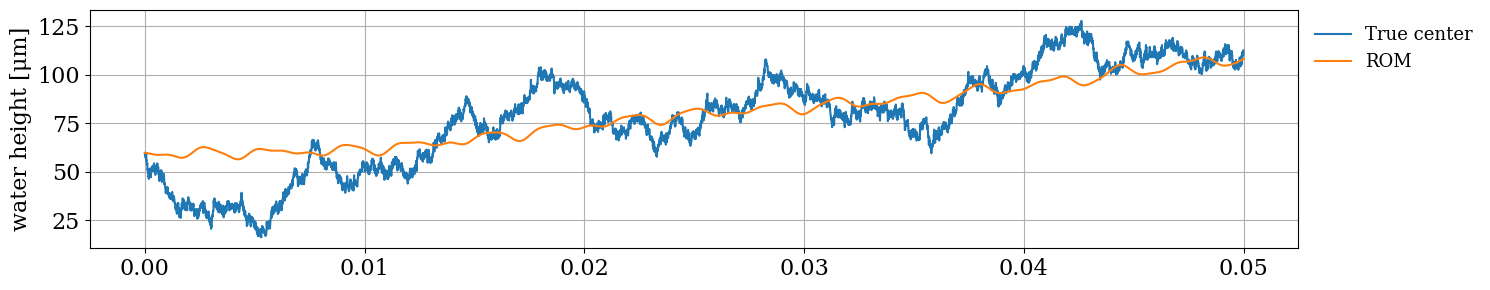

In [250]:
i_center = 100
Q_recon_center = Q_tilde[i_center, :]

plt.figure(figsize=(15, 3))
plt.plot(tt, Q_mean[i_center, :], label="True center")
plt.plot(tt, Q_recon_center, label=f"ROM")

plt.ylabel("water height [\u03bcm]", size=16)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.legend(fontsize=13, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.tight_layout()
plt.show()

In [251]:
np.savez(
    "detOpInf_0p35.npz",
    Q_tilde=Q_tilde, Q_mean=Q_mean, tt=tt)

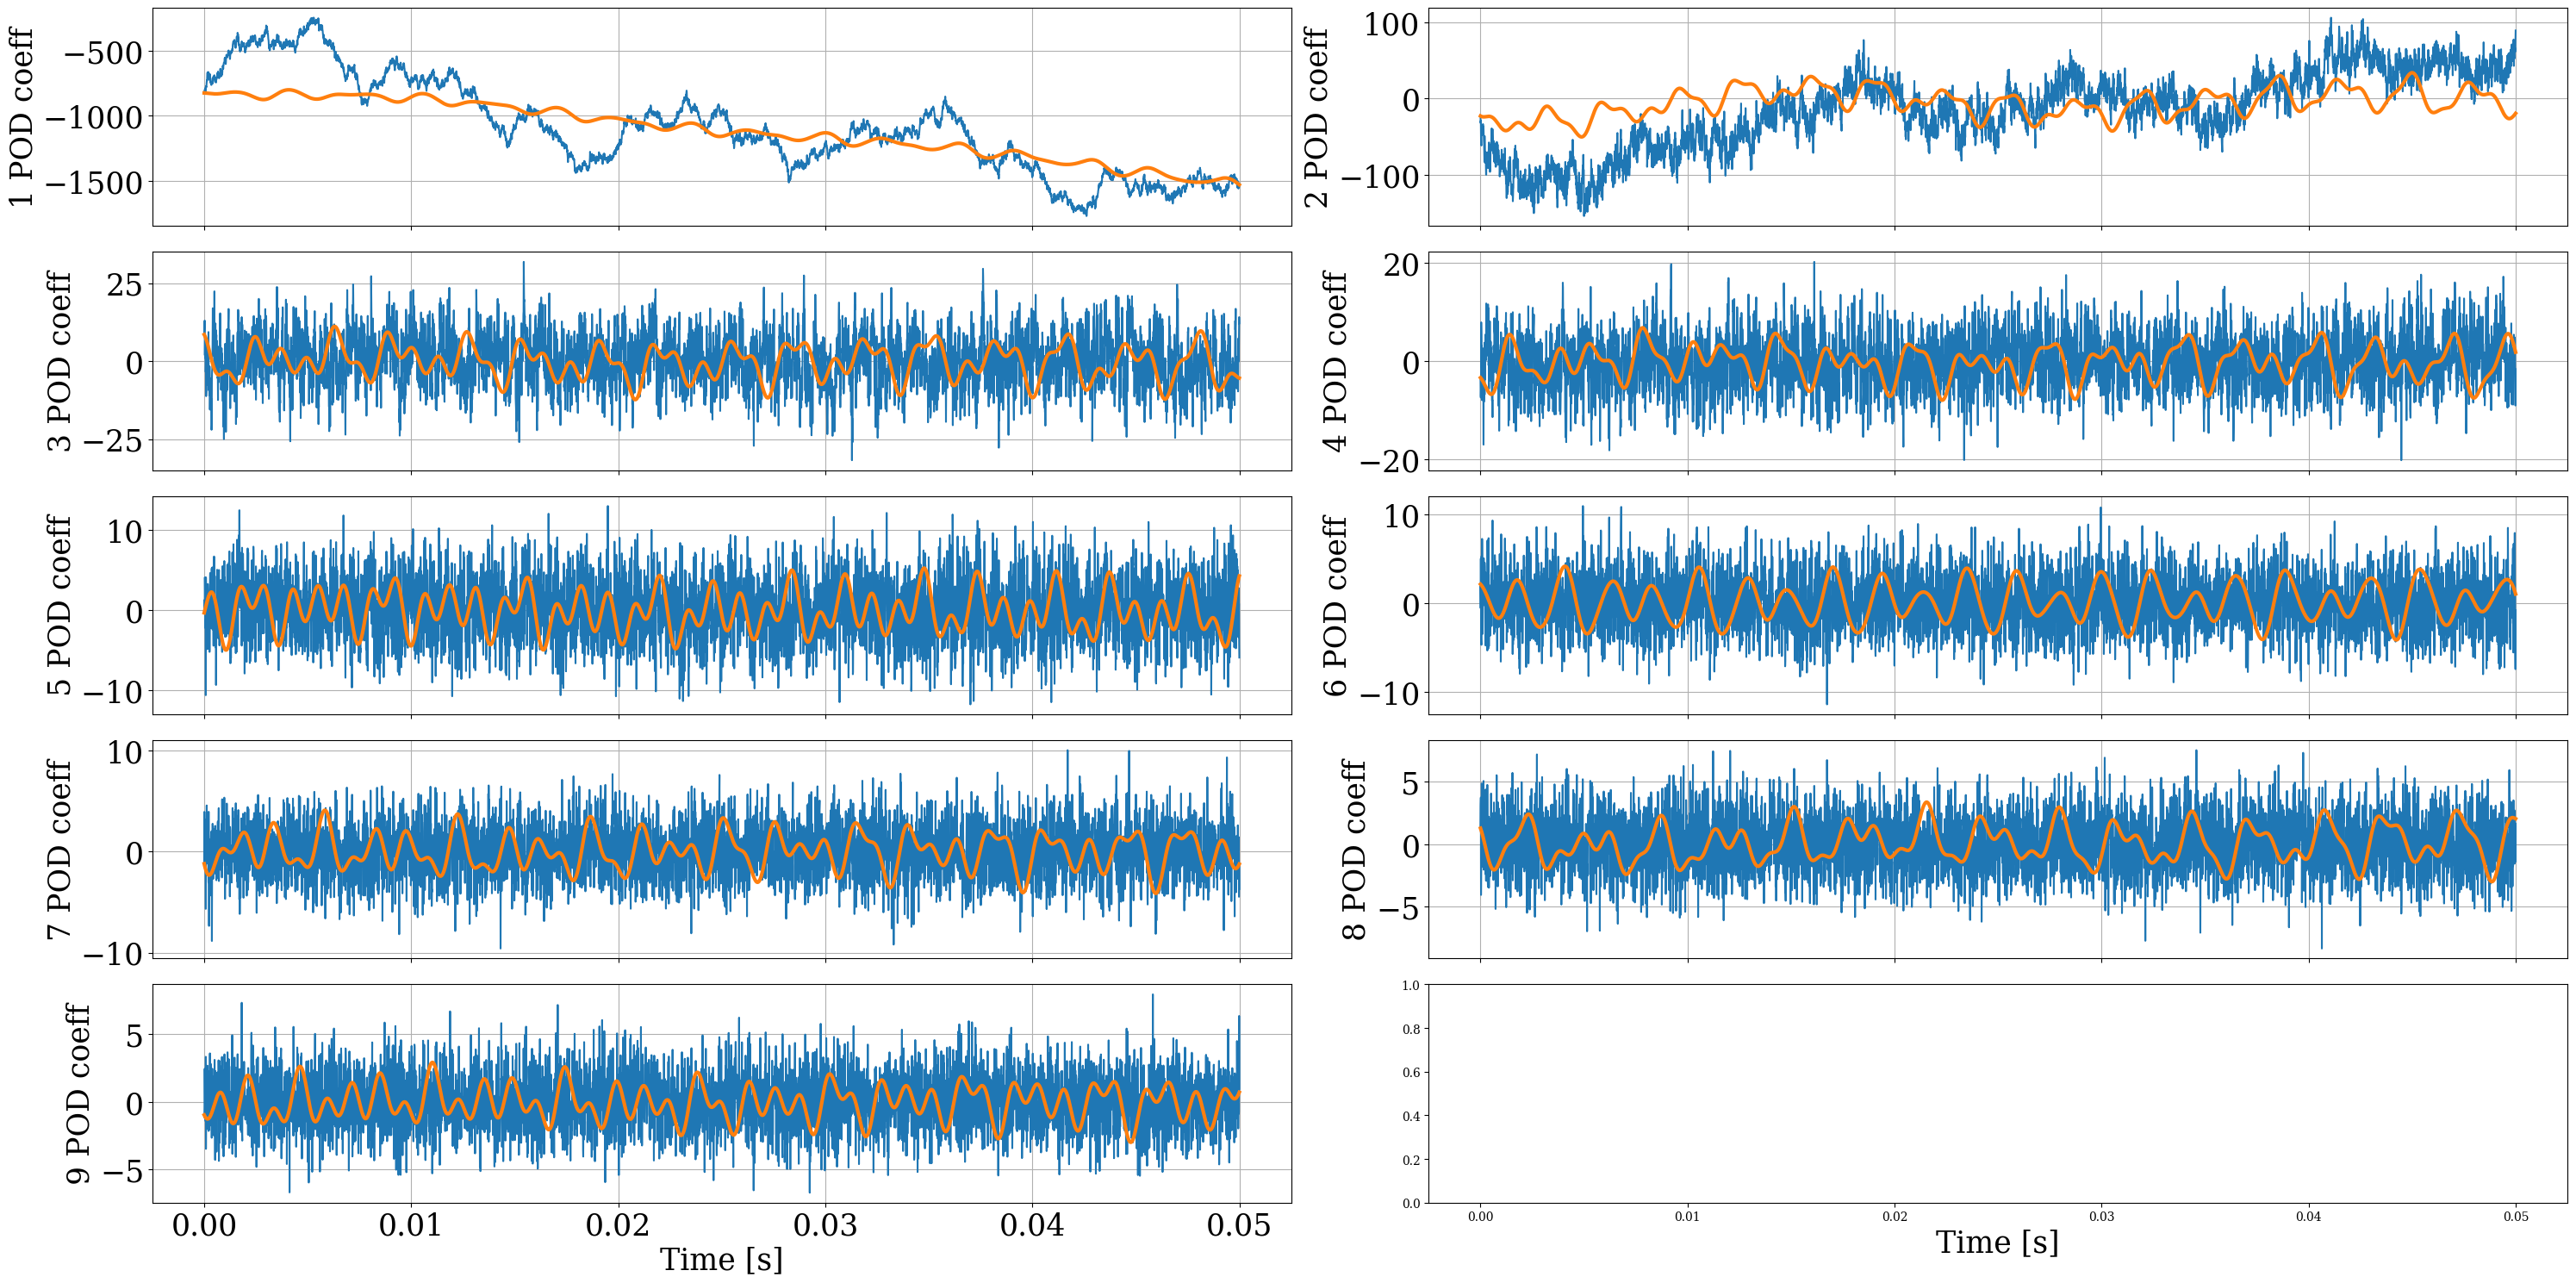

In [253]:
num_coeffs = 9

fig, axs = plt.subplots(5, 2, figsize=(30, 15), sharex=True)
axs = axs.flatten()
for ii in range(num_coeffs):
    axs[ii].plot(tt, Q_hat[ii,:], label="experiment", color='C0')
    axs[ii].plot(tt, q_hat_quadROM[ii,:], label="rom", color='C1', linewidth=3)
    axs[ii].set_ylabel(f"{ii+1} POD coeff", size=25)
    axs[ii].tick_params(axis='x', labelsize=25)
    axs[ii].tick_params(axis='y', labelsize=25)
    axs[ii].grid()
axs[-1].set_xlabel("Time [s]", size=25)
axs[-2].set_xlabel("Time [s]", size=25)
plt.tight_layout()
plt.show()